##### 1. Preparing Environment

In [26]:
%pip install pandas
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------------------ --------- 7.3/9.5 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 33.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 67.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 34.6 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
#Load data

data = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx"
)

##### 2. Data Analysis

    The first section aims to analyze the dataset in order to provide a better understanding for the user of it. A few tasks (1.-15.) are done
    in order to see some insights of the df in use.

    1.  - Loading the different Excel sheets into seperate variables
    2.  - Checking out data
    3.  - Finding the dimension of the dfs
    4.  - Examine Variable names
    5.  - Check out variable type
    6.  - Covnerting date columns
    7.  - Checking for missing values
    8.  - Generating descriptive statistics
    9.  - Analysing revenue as a Series
    10. - Comparing rainy and dry days
    11. - Creating total purchases
    12. - Validating the coffee quantities
    13. - Examining weather correlations
    14. - Create graph for revenue
    15. - Creating a reusable summary function

In [ ]:
#1. 

# Load the three Excel sheets into three separate dataframes

data_data = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Data"
)

data_forecast = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Weather forecasts"
)

data_legend = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Legend"
)

In [ ]:
#2.

display(data_legend.shape[0]) #row
display(data_legend.shape[1]) #column
display(data_data.shape)
display(data_forecast.shape)

#27
#2
#(294, 27)
#(8, 6)

27

2

(294, 27)

(8, 6)

In [ ]:
#3.

display(data_data.head(5))
display(data_forecast.head(3))
display(data_legend.head(27))

,date,tr,card,cash,q_1,q_2,q_3,q_4,q_5,q_6,...,tr_6,tr_7,tr_8,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2024-03-01,396.3,11,0,1,4,0,1,0,0,...,0.0,116.100002,77.400002,5.1,0.9,9.6,0.0,133.0,12.1,1021.5
1,2024-03-02,228.1,6,1,3,3,0,0,0,0,...,0.0,0.000000,40.000000,4.4,1.2,7.5,0.3,103.0,10.3,1019.1
2,2024-03-03,349.1,9,1,1,2,0,1,2,0,...,0.0,77.400002,78.700001,1.7,-3.4,7.0,0.0,96.0,9.3,1017.0
3,2024-03-04,135.2,4,0,0,1,0,0,0,1,...,24.0,0.000000,77.400002,5.1,1.6,10.9,0.0,140.0,13.8,1016.4
4,2024-03-05,338.5,9,0,0,0,0,1,1,0,...,0.0,154.800003,116.100002,5.4,-1.5,11.8,0.0,105.0,10.0,1016.1


,date,pres,wspd,wdir,tavg,prcp
0,2024-12-24,1017.812500,12.891667,76.750000,1.333333,0.4
1,2024-12-25,1031.858333,17.141667,20.500000,-0.058333,0.0
2,2024-12-26,1038.025000,14.416667,134.333328,-1.637500,0.4


,Variable name,Description
0,date,date
1,tr,Total Revenue from sales per day
2,card,Number of purchases with card
3,cash,Number of purchases with cash
4,q_1,"Americano, cups sold"
5,q_2,"Americano with Milk, cups sold"
6,q_3,"Cappuccino, cups sold"
7,q_4,"Cocoa, cups sold"
8,q_5,"Cortado, cups sold"
9,q_6,"Espresso, cups sold"


In [ ]:
#4.

data.columns

Index(['date', 'tr', 'card', 'cash', 'q_1', 'q_2', 'q_3', 'q_4', 'q_5', 'q_6',
       'q_7', 'q_8', 'tr_1', 'tr_2', 'tr_3', 'tr_4', 'tr_5', 'tr_6', 'tr_7',
       'tr_8', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres'],
      dtype='str')

In [ ]:
#5.

data.dtypes

#What is the type of data -> datetime64[us]
#What is the type of tr   -> float64
#What is the type of card -> int64



date    datetime64[us]
tr             float64
card             int64
cash             int64
q_1              int64
q_2              int64
q_3              int64
q_4              int64
q_5              int64
q_6              int64
q_7              int64
q_8              int64
tr_1           float64
tr_2           float64
tr_3           float64
tr_4           float64
tr_5           float64
tr_6           float64
tr_7           float64
tr_8           float64
tavg           float64
tmin           float64
tmax           float64
prcp           float64
wdir           float64
wspd           float64
pres           float64
dtype: object

In [ ]:
#6.

data_data["date"] = pd.to_datetime(data_data["date"])
data_forecast["date"] = pd.to_datetime(data_forecast["date"])

print(data_data["date"].dtypes)
print(data_forecast["date"].dtypes)

datetime64[us]
datetime64[us]


In [ ]:
#7.

data.isnull().sum()

date     0
tr       0
card     0
cash     0
q_1      0
q_2      0
q_3      0
q_4      0
q_5      0
q_6      0
q_7      0
q_8      0
tr_1     0
tr_2     0
tr_3     0
tr_4     0
tr_5     0
tr_6     0
tr_7     0
tr_8     0
tavg     0
tmin     0
tmax     0
prcp     0
wdir     4
wspd    11
pres    11
dtype: int64

In [35]:
#8.

data_data.describe()

#What is the average daily revenue?             -> 284
#What is the minimum daily revenue?             -> 1
#What is the maximum daily revenue?             -> 836
#What is the average temperature?               -> 20
#What is the maximum recorded precipitation?    -> 5

,date,tr,card,cash,q_1,q_2,q_3,q_4,q_5,q_6,...,tr_8,tavg,tmin,tmax,prcp,wdir,wspd,pres,total_cups,total_purchases
count,294,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,...,294.000000,294.000000,294.000000,294.000000,294.000000,290.000000,283.000000,283.000000,294.000000,294.000000
mean,2024-07-27 22:51:25.714285,284.510544,8.619048,0.302721,1.112245,2.112245,1.251701,0.472789,0.840136,0.329932,...,74.835577,13.508844,8.158163,19.447959,1.745918,183.094828,11.836749,1016.844170,8.921769,8.921769
min,2024-03-01 00:00:00,23.020000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-7.300000,-13.300000,-2.600000,0.000000,0.100000,5.000000,998.000000,1.000000,1.000000
25%,2024-05-16 06:00:00,175.635000,5.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,35.759998,5.400000,1.425000,11.225000,0.000000,91.750000,8.800000,1011.700000,6.000000,6.000000
50%,2024-07-28 12:00:00,271.540000,8.000000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,71.519997,14.900000,8.500000,22.000000,0.000000,177.500000,11.200000,1016.400000,8.000000,8.000000
75%,2024-10-09 18:00:00,370.330000,11.000000,0.000000,2.000000,3.000000,2.000000,1.000000,1.000000,0.000000,...,111.690001,20.575000,14.600000,28.100000,1.150000,287.000000,13.550000,1020.850000,11.000000,11.000000
max,2024-12-23 00:00:00,836.660000,26.000000,4.000000,5.000000,12.000000,9.000000,6.000000,5.000000,4.000000,...,321.839985,34.300000,23.400000,39.200000,29.000000,359.000000,29.200000,1035.000000,26.000000,26.000000
std,NaN,145.429385,4.763819,0.715641,1.218873,1.977084,1.289726,0.880743,1.070049,0.663522,...,61.770504,8.635323,7.258371,10.631374,3.861921,106.233189,4.152201,7.425932,4.641113,4.641113


In [ ]:
#9.

revenue = data_data["tr"]
revenue.describe()

count    294.000000
mean     284.510544
std      145.429385
min       23.020000
25%      175.635000
50%      271.540000
75%      370.330000
max      836.660000
Name: tr, dtype: float64

In [ ]:
#10.

rainy_days = data[data["prcp"] > 0]
dry_days = data[data["prcp"] == 0]

print(f"Number of rainy days: {rainy_days.shape[0]}")
print(f"Number of dry days: {dry_days.shape[0]}")

Number of rainy days: 136
Number of dry days: 158


In [ ]:
#11.

data_data["total_purchases"] = data_data["card"] + data_data["cash"]

display(data_data[
    ["total_purchases", "card", "cash"]
    ].head(5))

print(f"Average purchase a day: {data_data['total_purchases'].mean()}")

,total_purchases,card,cash
0,11,11,0
1,7,6,1
2,10,9,1
3,4,4,0
4,9,9,0


Average purchase a day: 8.921768707482993


In [ ]:
#12.1

data_data["total_cups"] = (
    data_data["q_1"] 
    + data_data["q_2"] 
    + data_data["q_3"] 
    + data_data["q_4"] 
    + data_data["q_5"] 
    + data_data["q_6"] 
    + data_data["q_7"] 
    + data_data["q_8"]
)

display(data_data[
    ["total_cups", "q_1", "q_2"]
    ].head(5))

,total_cups,q_1,q_2
0,11,1,4
1,7,3,3
2,10,1,2
3,4,0,1
4,9,0,0


In [ ]:
#12.2

data_data["purchase_match"] = (
    data_data["total_purchases"] == data_data["total_cups"]
)


display(
    data_data["purchase_match"].value_counts()
)


purchase_match
True    294
Name: count, dtype: int64

In [ ]:
#13.

correlation_data = data_data[
    ["tr", "tavg", "prcp", "wspd", "pres"]
]

correlation_matrix = correlation_data.corr()

correlation_matrix["tr"]

#Is revenue positively or negatively correlated with average temperature?               -> negatively correlated
#Which selected weather variable has the strongest absolute correlation with revenue?   -> pres (Air pressure)
#Does a correlation close to zero suggest a strong linear relationship?                 -> No, it suggests little to no linear relationship

tr      1.000000
tavg   -0.129853
prcp   -0.008940
wspd   -0.009434
pres    0.190279
Name: tr, dtype: float64

<Axes: title={'center': 'Daily Revenue Over Time'}, xlabel='date'>

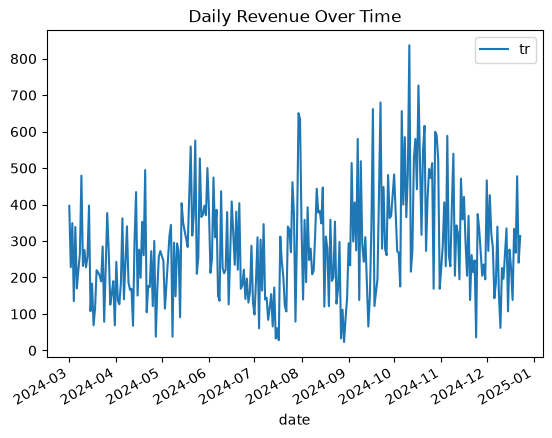

In [ ]:
#14.

data_data.plot.line(
    x = "date",
    y = "tr",
    title = "Daily Revenue Over Time",
)

In [36]:
#15.

def summarize_data(df, column):
    summary = {
        "mean": df[column].mean(),
        "median": df[column].median(),
        "std_dev": df[column].std(),
        "min": df[column].min(),
        "max": df[column].max()
    }
    return summary

summarize_data(data_data, "tr")

{'mean': np.float64(284.510544217687),
 'median': np.float64(271.53999999999996),
 'std_dev': np.float64(145.42938476789698),
 'min': np.float64(23.02),
 'max': np.float64(836.6599999999999)}

##### 3. Forecasting Analysis

    - As a forecasting analysis a few operations will be tested on the data set, with the aim to collect data for a theoretical "executive summary"

    1. What is the main variable ? Does it have seasonality or trend? (2 solutions)
    2. Which variable could be selected as the primary focus to describe the main variable?
    3. Based on (1.) and (2.) run a regression to get relationship. What properties needs to be considered, is it going to be a static or predictive regression?
    4. Split data, use train set for regressio nestimation, estimate residiuals as well as its test set performance
    5. Forecast for December month
    6. Estimate ARIMA, evaluate model perofrmance
    7. Forecast with ARIMA
    8. Compare models, is it good to compare?
    9. Estimate forecast combination with equal and GR weights
    10. Give an answer which is the best forecast
            - regression
            - ARIMA
            - model combination

In [71]:
%pip install tkinter
%pip install statsmodels
%pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tkinter (from versions: none)

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tkinter


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/723.3 kB ? eta -:--:--
   ---------------------------------------- 723.3/723.3 kB 25.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 69.9 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 44.4 MB/s  0:00:00
   ---------------------------------------- 0.0/818.2 kB ? eta -:--:--
   ---------------------------------------- 818.2/818.2 kB 32.2 MB/s  0:00:00

   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------- ----------------------------- 2/8 [setuptools]
   ---------- ----------------------------- 2/8 [setuptools]
   ---------- ----------------------------- 2/8 [setuptools]
   ---------- ----------------------------- 2/8 [setuptool

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pmdarima as pm

from statsmodels.tsa.stattools import adfuller                  #for stationarity check
from statsmodels.tsa.seasonal import seasonal_decompose         #for decomposition
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   #for stationarity check

import statsmodels.formula.api as smf                           #for regression analysis

In [3]:
#0. Load data

data_sales = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Data"
)

data_forecast = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Weather forecasts"
)

data_legend = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Legend"
)

count    294.0
mean     285.0
std      145.0
min       23.0
25%      176.0
50%      272.0
75%      370.0
max      837.0
Name: tr, dtype: float64

count    293.0
mean      -0.0
std      176.0
min     -621.0
25%     -121.0
50%        6.0
75%      129.0
max      481.0
Name: tr, dtype: float64

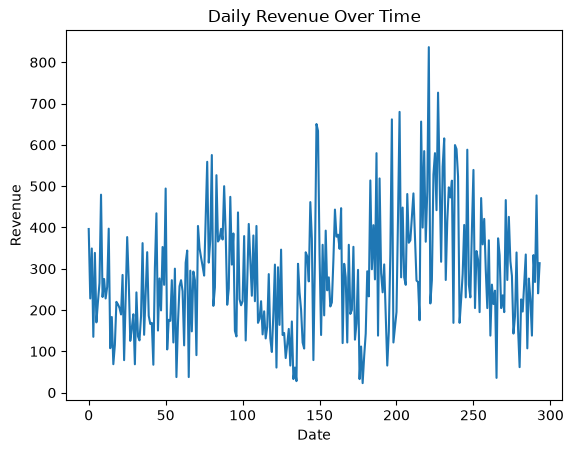

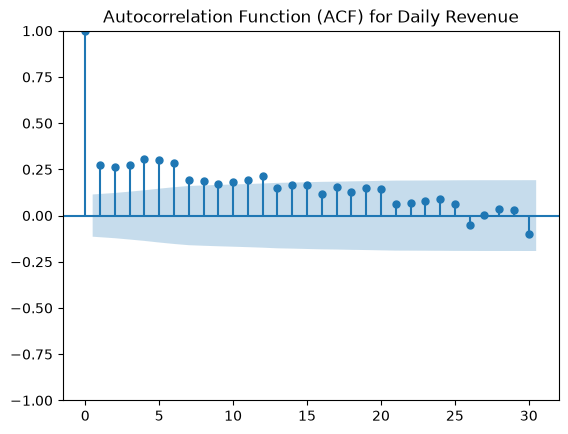

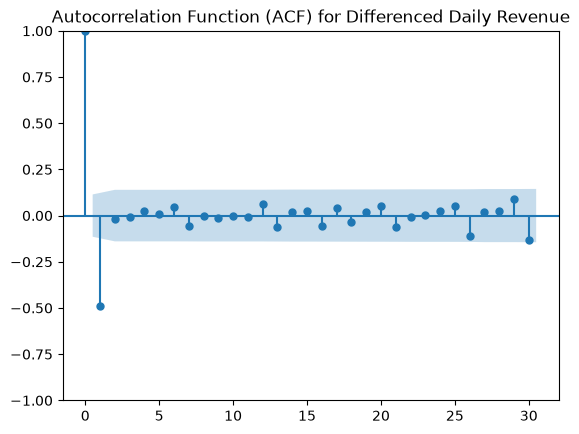

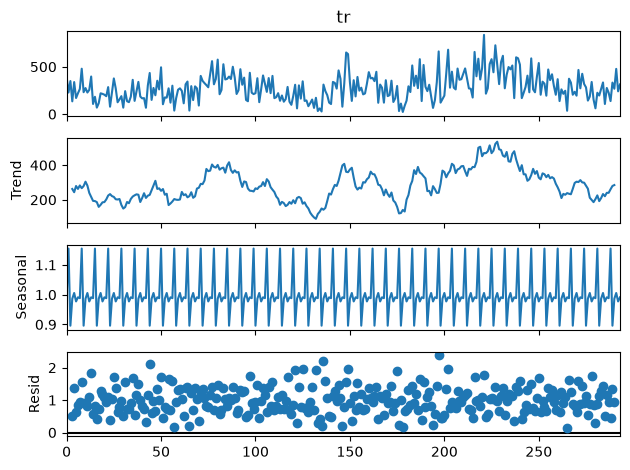

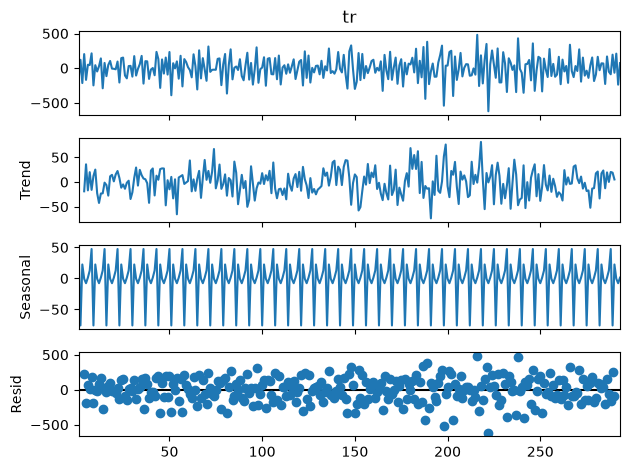

In [4]:
#1. Check for dynamic properties = how variable behaves over time.


#Define variable
y = data_sales["tr"]

#Plot the time series data
plot = y.plot(
    title = "Daily Revenue Over Time",
    xlabel = "Date",
    ylabel = "Revenue"
)

#Check stationarity 

#The relationship of past values to current are stable and can be used therefore
        #stable mean
        #stable variance
        #stable dependence on past values

#I.
adf_result = adfuller(y.dropna())
adf_pvalue = adf_result[1]
adf_pvalue

#II.
plot_acf(y,
         lags = 30,
         title = "Autocorrelation Function (ACF) for Daily Revenue"
);

#Differencing 

#Changes question from "What is value today" to "How much it changed form yesterday"

#It shifts the data to remove trend and seasonality, 
# making it easier to analyze the underlying patterns.

dy = y.diff().dropna()

#Check stationarity of differenced data
display(y.describe().round())
display(dy.describe().round())

#Plot dy

#II.
plot_acf(dy,
         lags = 30,
         title = "Autocorrelation Function (ACF) for Differenced Daily Revenue"
);

#Check seasonality y,yd

y_decomp = seasonal_decompose(y,
                              model = "multiplicative",
                              period = 7)
plot = y_decomp.plot()

dy_decomp = seasonal_decompose(dy,
                               model = "additive",
                               period = 7)
plot = dy_decomp.plot()

In [5]:
#2. Choosing independent variables

#Checking description of variables

display(data_legend.describe())
display(data_legend.head(27))

#Defining independent variables

x1 = data_sales["tavg"]
x2 = data_sales["tmax"]
x3 = data_sales["tmin"]

adf_result_x1 = adfuller(x1)
adf_result_x2 = adfuller(x2)
adf_result_x3 = adfuller(x3)

print(f"ADF p-value for x1 (tavg): {adf_result_x1[1]}")
print(f"ADF p-value for x2 (tmax): {adf_result_x2[1]}")
print(f"ADF p-value for x3 (tmin): {adf_result_x3[1]}")

dx1 = x1.diff().dropna()
dx2 = x2.diff().dropna()
dx3 = x3.diff().dropna()



,Variable name,Description
count,27,27
unique,27,27
top,date,date
freq,1,1


,Variable name,Description
0,date,date
1,tr,Total Revenue from sales per day
2,card,Number of purchases with card
3,cash,Number of purchases with cash
4,q_1,"Americano, cups sold"
5,q_2,"Americano with Milk, cups sold"
6,q_3,"Cappuccino, cups sold"
7,q_4,"Cocoa, cups sold"
8,q_5,"Cortado, cups sold"
9,q_6,"Espresso, cups sold"


ADF p-value for x1 (tavg): 0.6265888781585394
ADF p-value for x2 (tmax): 0.5497613139637981
ADF p-value for x3 (tmin): 0.603450178194449


In [6]:
x4 = data_sales["prcp"]
adf_result_x4 = adfuller(x4)
print(f"ADF p-value for x4 (prcp): {adf_result_x4[1]}")
dx4 = x4.diff().dropna()

ADF p-value for x4 (prcp): 5.519766405050118e-27


MODEL 1
                            OLS Regression Results                            
Dep. Variable:                     dy   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3740
Date:                Tue, 11 Aug 2026   Prob (F-statistic):              0.541
Time:                        12:08:35   Log-Likelihood:                -1929.5
No. Observations:                 293   AIC:                             3863.
Df Residuals:                     291   BIC:                             3870.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3521     10.276     -0.034 

<Axes: xlabel='prcp', ylabel='tr'>

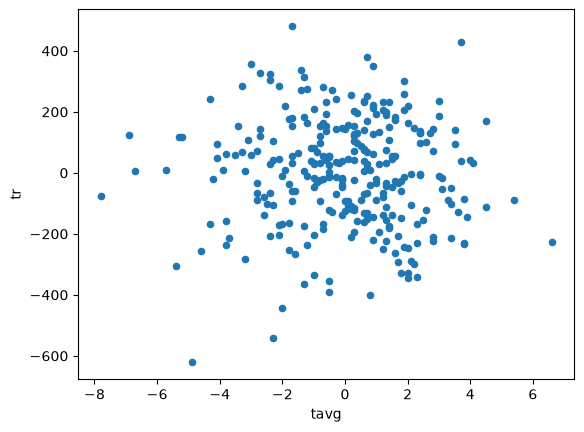

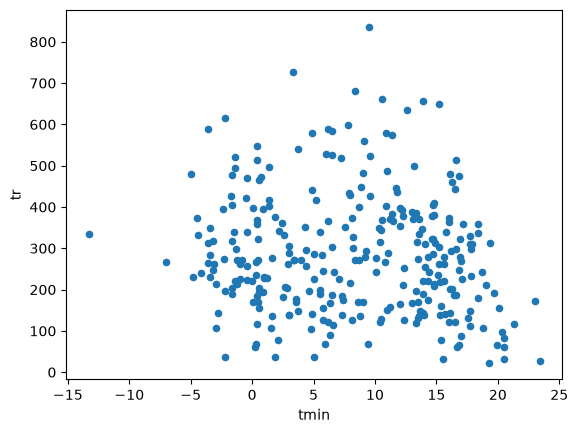

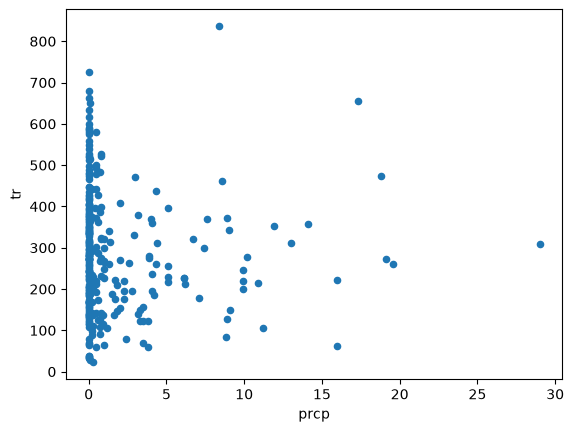

In [13]:
#3. Run regression to get relationship

#Bring time series data together

data_sales_same_length = pd.concat(
    [dy, dx1],
    axis = 1
)

data_sales_c = data_sales_same_length.dropna()


#Regression analysis on dx1

regression_model_1 = smf.ols(
    formula = "dy ~ dx1",
    data = data_sales_c
).fit()



#Regression analysis on dx2,dx3

regression_model_2 = smf.ols(
    formula = "dy ~ dx2 + dx3",
    data = data_sales_c
).fit()


print("MODEL 1")
print(regression_model_1.summary())
print("MODEL 2")
print(regression_model_2.summary())

#Check relationships visually

#dx1 - none
data_sales_c.plot.scatter(
    x="tavg",
    y="tr"
)

#dx3

data_sales.plot.scatter(
 x = "tmin",
 y = "tr"   
)

#Regression analysis on dx4 (precipitation)

regression_model_3 = smf.ols(
    formula = "dy ~ dx4",
    data = data_sales_c
).fit()

print("MODEL 3")
print(regression_model_3.summary())

#Plot it

data_sales.plot.scatter(
    x = "prcp",
    y = "tr"
)

#statistically significant ≠ practically powerful predictor.
#R² = 0.017 means precipitation changes explain only about 1.7% of the variation in revenue changes.

(244, 2)
(49, 2)


count     49.0
mean      -2.0
std      169.0
min     -334.0
25%     -123.0
50%      -30.0
75%      142.0
max      360.0
dtype: float64

Test RMSE: 167.53700817421637
Test MAE: 141.0216544983935


count     49.0
mean      -2.0
std      169.0
min     -334.0
25%     -123.0
50%      -30.0
75%      142.0
max      360.0
dtype: float64

Test RMSE: 167.53700817421637
Test MAE: 141.0216544983935


,actual,predicted,error
245,-175.36,1.166759,-176.526759
246,357.60,-2.355666,359.955666
247,-326.74,1.647090,-328.387090
248,-30.86,-0.674508,-30.185492
249,164.10,-0.914674,165.014674
250,144.50,2.287531,142.212469
251,-334.56,-0.754563,-333.805437
252,138.14,-0.434343,138.574343
253,-21.06,-0.514398,-20.545602
254,-126.88,-0.274233,-126.605767


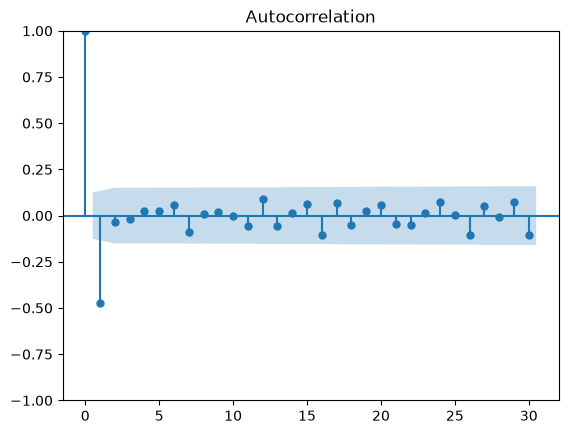

In [ ]:
#4. Split, run regression estimation, residuals, test

#Create clear variable names for regression

data_sales_c = pd.DataFrame({
    "dy": dy,
    "dx1": dx1
}).dropna()

#Split oos = 49

train_data = data_sales_c.iloc[:244]
test_data = data_sales_c.iloc[244:] #integer location

print(train_data.shape)
print(test_data.shape)

#Run regression on training data

#not actually estimated the regression yet. 
# - “I want an OLS regression where dy is explained by dx1, using train_data.”

regression_model_train = smf.ols(
    formula = "dy ~ dx1",
    data = train_data
)

#Estimate residuals

residuals_train = regression_model_train.fit().resid

plot_acf(residuals_train, lags=30);

#Fit the model

#where the actual learning/calculation happens.

fitted_model = regression_model_train.fit()


##Calculate residuals for test data



test_predictions = fitted_model.predict(test_data)

test_errors = test_data["dy"] - test_predictions

display(test_errors.describe().round()) 

# Performance
rmse = np.sqrt(np.mean(test_errors ** 2))
mae = np.mean(np.abs(test_errors))

print("Test RMSE:", rmse)
print("Test MAE:", mae) 

#RMSE - It also measures how far predictions are from reality, but it punishes large mistakes more heavily.
#MAE - “On average, how far were my predictions from what actually happened?”


##Calculate residuals for test data



test_predictions = fitted_model.predict(test_data)

test_errors = test_data["dy"] - test_predictions

display(test_errors.describe().round()) 

# Performance
rmse = np.sqrt(np.mean(test_errors ** 2))
mae = np.mean(np.abs(test_errors))

print("Test RMSE:", rmse)
print("Test MAE:", mae) 

#RMSE - It also measures how far predictions are from reality, but it punishes large mistakes more heavily.
#MAE - “On average, how far were my predictions from what actually happened?”


##Actual vs Predicted

performance = pd.DataFrame({
    "actual": test_data["dy"],
    "predicted": test_predictions,
    "error": test_errors
})

performance.head(10)

In [61]:
#5. Forecast for december month

#Create final regression on all data to use for forecasting
final_regression = smf.ols(
    formula="dy ~ dx1",
    data=data_sales_c
).fit()

#Create a new dataframe for the forecast period


# Calculate temperature changes between future days
future["dx1"] = future["tavg"].diff()

# Fix the first future day:
# Dec 24 temperature - Dec 23 temperature
future.loc[future.index[0], "dx1"] = (
    future["tavg"].iloc[0] - data_sales["tavg"].iloc[-1]
)

# Predict future changes in revenue
future["predicted_dy"] = final_regression.predict(future)

# Convert predicted changes back into revenue levels
last_revenue = data_sales["tr"].iloc[-1]

future["forecast_tr"] = (
    last_revenue + future["predicted_dy"].cumsum()
)

# Show forecast
future[["date", "tavg", "dx1", "predicted_dy", "forecast_tr"]]


,date,tavg,dx1,predicted_dy,forecast_tr
0,2024-12-24,1.333333,3.433333,-10.063132,303.436868
1,2024-12-25,-0.058333,-1.391667,3.584170,307.021038
2,2024-12-26,-1.637500,-1.579167,4.114505,311.135543
3,2024-12-27,-0.166667,1.470833,-4.512286,306.623257
4,2024-12-28,-0.250000,-0.083333,-0.116394,306.506863
5,2024-12-29,0.475000,0.725000,-2.402729,304.104134
6,2024-12-30,1.350000,0.875000,-2.826998,301.277136
7,2024-12-31,2.050000,0.700000,-2.332018,298.945118


In [81]:
#6. Estimate ARIMA

#Split again for ARIMA model but without differencing (it can do internally)

y = data_sales["tr"]

train_data_arima = y.iloc[:244]
test_data_arima = y.iloc[245:]

print("Train data shape:", train_data_arima.shape)
print("Test data shape:", test_data_arima.shape)

#Train ARIMA

arima_model = pm.auto_arima(
    train_data_arima,
    seasonal=True,          #check for seasonality
    m=7,                    #weekly seasonality
    stepwise=True,          #find best model quickly
    suppress_warnings=True,  #don't show warnings
    trace=True
)

print(arima_model.summary())

Train data shape: (244,)
Test data shape: (49,)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=3087.783, Time=0.89 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=3209.817, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=3149.386, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=3081.602, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=3207.818, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=3081.167, Time=0.05 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=3081.581, Time=0.13 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=3083.469, Time=0.31 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=3083.161, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=3083.163, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=3149.554, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=3085.026, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[7]             : AIC=3079.282, Time=0.04 sec
 ARIMA(0,1,1)(1,0,0)[7]             : AIC=3079.707,

In [82]:
#7. Forecast with ARIMA

final_arima_model = pm.ARIMA(                   #cuz we already have best
    order=arima_model.order,
    seasonal_order=arima_model.seasonal_order
)

final_arima_model.fit(y)

# Number of future days
n_future = len(data_forecast)

# Forecast + 95% confidence interval
arima_forecast, conf_int = final_arima_model.predict(
    n_periods=n_future,
    return_conf_int=True,
    alpha=0.05
)

arima_future = pd.DataFrame(
    {
    "date": data_forecast["date"].to_numpy(),
    "arima_forecast": np.asarray(arima_forecast),
    "lower_95": conf_int[:, 0],
    "upper_95": conf_int[:, 1]
}
)

arima_future

,date,arima_forecast,lower_95,upper_95
0,2024-12-24,277.661367,18.576447,536.746286
1,2024-12-25,277.675588,15.498861,539.852315
2,2024-12-26,277.689808,12.457312,542.922305
3,2024-12-27,277.704029,9.450571,545.957487
4,2024-12-28,277.718250,6.477474,548.959026
5,2024-12-29,277.732471,3.536922,551.928020
6,2024-12-30,277.746692,0.627873,554.865511
7,2024-12-31,277.760913,-2.250660,557.772485


In [ ]:
#7. Combine forecasts from regression and ARIMA with equal and GR

#Equal-weight combination 50-50
equal_forecast = (
    0.5 * regression_test_forecast.to_numpy()
    + 0.5 * np.asarray(arima_test_forecast)
)



In [ ]:
#Granger–Ramanathan combination - learns the weights from the 49 test observations

gr_model = smf.ols(
    formula="actual ~ regression + arima",
    data=combination_data
).fit()

print(gr_model.summary())